**Install Libraries**

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow tqdm --quiet
print("Done!")

Done!


**Upload and unzip the dataset**

In [5]:
from google.colab import files
import zipfile, os

# Upload your zipped dataset
uploaded = files.upload()  # Select your cinnamon_dataset.zip

# Unzip it
for filename in uploaded:
    with zipfile.ZipFile(filename, 'r') as z:
        z.extractall('/content/')
    print(f"Unzipped: {filename}")

print("Folder contents:", os.listdir('/content/cinnamon_dataset'))

Saving cinnamon_dataset.zip to cinnamon_dataset.zip
Unzipped: cinnamon_dataset.zip
Folder contents: ['val', 'train', 'test']


**Configuration**

In [6]:
import os, random, numpy as np, warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Config
BASE_DIR    = '/content/cinnamon_dataset'
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'val')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
MODEL_PATH  = '/content/cinnamon_model.keras'

CLASSES     = ['Healthy', 'Rough_Bark_Disease', 'Stripe_Canker']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Config ready!")

TensorFlow: 2.19.0
GPU: False
Config ready!


**Check Dataset & Visualize Samples**

Dataset Summary:

  [Train]
    Healthy                   1248 images
    Rough_Bark_Disease        126 images
    Stripe_Canker             134 images

  [Val]
    Healthy                   139 images
    Rough_Bark_Disease        16 images
    Stripe_Canker             17 images

  [Test]
    Healthy                   76 images
    Rough_Bark_Disease        16 images
    Stripe_Canker             17 images



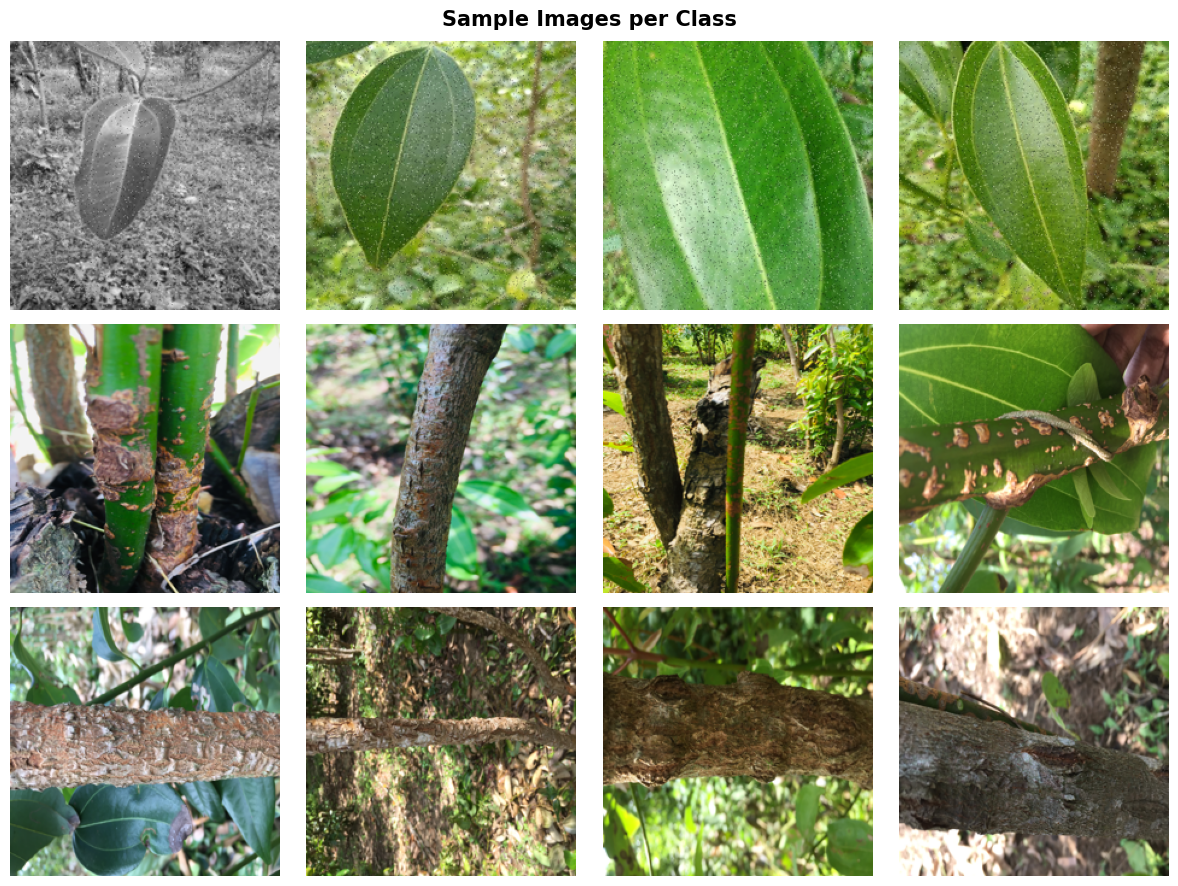

In [7]:
# Count images per class
print("Dataset Summary:\n")
for split, split_dir in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    print(f"  [{split}]")
    for cls in CLASSES:
        path = os.path.join(split_dir, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:<25} {count} images")
    print()

# Show sample images from each class
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, len(CLASSES) * 3))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images  = os.listdir(cls_dir)[:4]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(cls_dir, img_name)).resize((IMG_SIZE, IMG_SIZE))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.replace('_', '\n'), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Data Augmentation & Generators**

In [8]:
import math

# Augmentation for training only
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=True, seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    classes=CLASSES, shuffle=False
)

# Calculate class weights to fix imbalance
total_images = 1248 + 126 + 134   # update these numbers to match yours
n_classes = 3

class_counts = {
    0: 1248,   # Healthy
    1: 126,    # Rough_Bark_Disease
    2: 134     # Stripe_Canker
}

class_weights = {
    cls: total_images / (n_classes * count)
    for cls, count in class_counts.items()
}

print("Class Weights (higher = more attention during training):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:<25} weight = {class_weights[i]:.2f}")

print(f"\nTrain: {train_gen.n} | Val: {val_gen.n} | Test: {test_gen.n}")

Found 1508 images belonging to 3 classes.
Found 172 images belonging to 3 classes.
Found 109 images belonging to 3 classes.
Class Weights (higher = more attention during training):
  Healthy                   weight = 0.40
  Rough_Bark_Disease        weight = 3.99
  Stripe_Canker             weight = 3.75

Train: 1508 | Val: 172 | Test: 109


**Build the Model**

In [9]:
def build_model():
    base = EfficientNetB3(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False  # Freeze base for Phase 1

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

model, base_model = build_model()
model.summary()
print("Model built!")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,708,722 (44.67 MB)

 Trainable params: 922,115 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

Model built!


**Phase 1 Training (Frozen Base)**

In [10]:
callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Phase 1: Training with class weights to fix imbalance...")
history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights,   # KEY FIX
    verbose=1
)
print(f"Best Val Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training with class weights to fix imbalance...
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5809 - loss: 1.7975
Epoch 1: val_accuracy improved from None to 0.09302, saving model to /content/cinnamon_model.keras

Epoch 1: finished saving model to /content/cinnamon_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.5040 - loss: 2.1743 - val_accuracy: 0.0930 - val_loss: 2.2192 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4757 - loss: 2.0082
Epoch 2: val_accuracy did not improve from 0.09302
48/48 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.4755 - loss: 1.7360 - val_accuracy: 0.0930 - val_loss: 1.2134 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4162 - loss: 1.4821
Epoch 3: val_accuracy did not improve from 0.09302
48/48 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.4390 - loss: 1.4414 - val_accuracy: 0.0930 - val_loss: 1.1309 - learning_rate: 0.0010
Epoch 4/

**Phase 2 Fine-Tuning**

In [11]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning top 30 layers...")
history2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights,   # KEY FIX
    verbose=1
)
print(f"Best Val Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Fine-tuning top 30 layers...
Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5383 - loss: 1.1068
Epoch 1: val_accuracy improved from 0.55814 to 0.79651, saving model to /content/cinnamon_model.keras

Epoch 1: finished saving model to /content/cinnamon_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.5458 - loss: 1.0818 - val_accuracy: 0.7965 - val_loss: 0.8020 - learning_rate: 1.0000e-05
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5552 - loss: 1.1105
Epoch 2: val_accuracy improved from 0.79651 to 0.80233, saving model to /content/cinnamon_model.keras

Epoch 2: finished saving model to /content/cinnamon_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.5584 - loss: 1.0639 - val_accuracy: 0.8023 - val_loss: 0.7756 - learning_rate: 1.0000e-05
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5299 - loss: 1.0990
Epoch 3: val_accuracy did not improve from 0.80233
48/48 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accurac

 **Plot Training Curves**

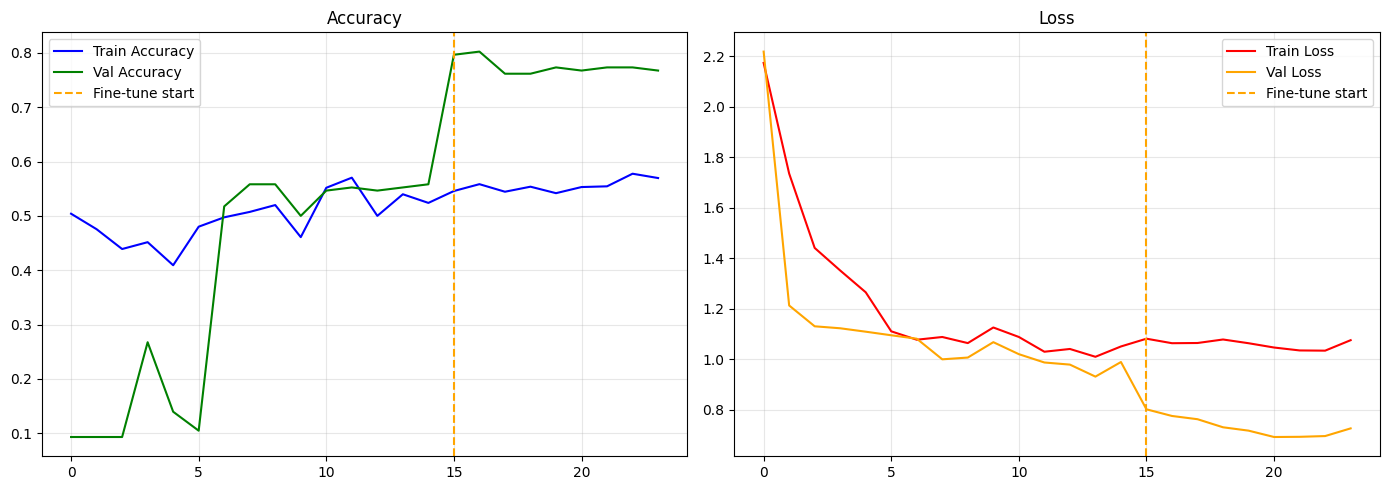

In [12]:
# Combine both phases
acc  = history1.history['accuracy']    + history2.history['accuracy']
val  = history1.history['val_accuracy']+ history2.history['val_accuracy']
loss = history1.history['loss']        + history2.history['loss']
v_loss=history1.history['val_loss']   + history2.history['val_loss']
p1_end = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Train Accuracy', color='blue')
ax1.plot(val, label='Val Accuracy', color='green')
ax1.axvline(p1_end, color='orange', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(loss, label='Train Loss', color='red')
ax2.plot(v_loss, label='Val Loss', color='orange')
ax2.axvline(p1_end, color='orange', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluate on Test Set**

4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7339 - loss: 0.8356

Test Accuracy : 73.39%
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step

Classification Report:
                    precision    recall  f1-score   support

           Healthy       0.81      0.93      0.87        76
Rough_Bark_Disease       0.43      0.56      0.49        16
     Stripe_Canker       0.00      0.00      0.00        17

          accuracy                           0.73       109
         macro avg       0.41      0.50      0.45       109
      weighted avg       0.63      0.73      0.68       109



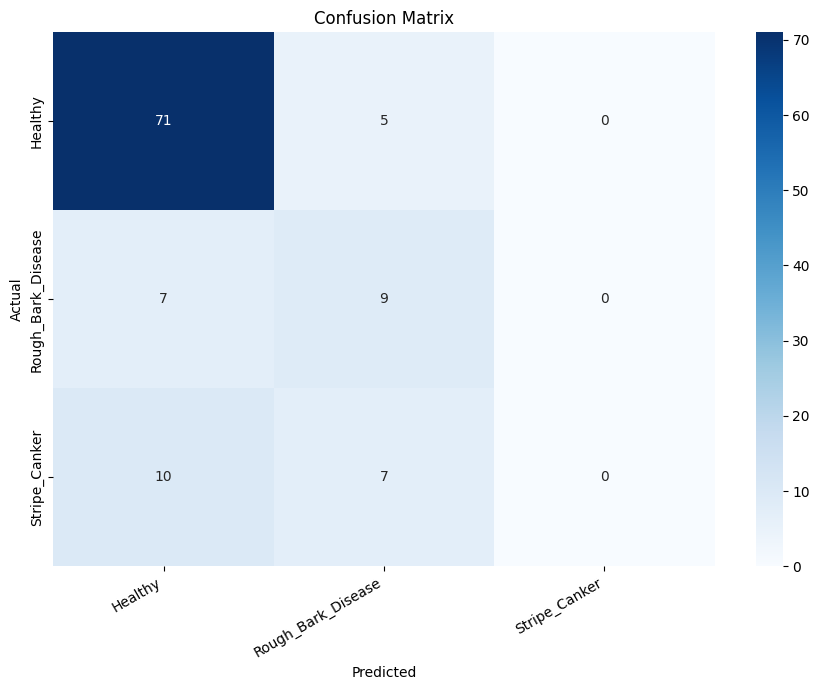

In [13]:
# Load best model
best_model = keras.models.load_model(MODEL_PATH)

# Evaluate
results = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {results[1]*100:.2f}%")

# Confusion matrix
test_gen.reset()
y_pred = np.argmax(best_model.predict(test_gen), axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Predict on a New Image**

Upload a cinnamon plant image:


Saving IMG_E4843.JPG to IMG_E4843 (1).JPG


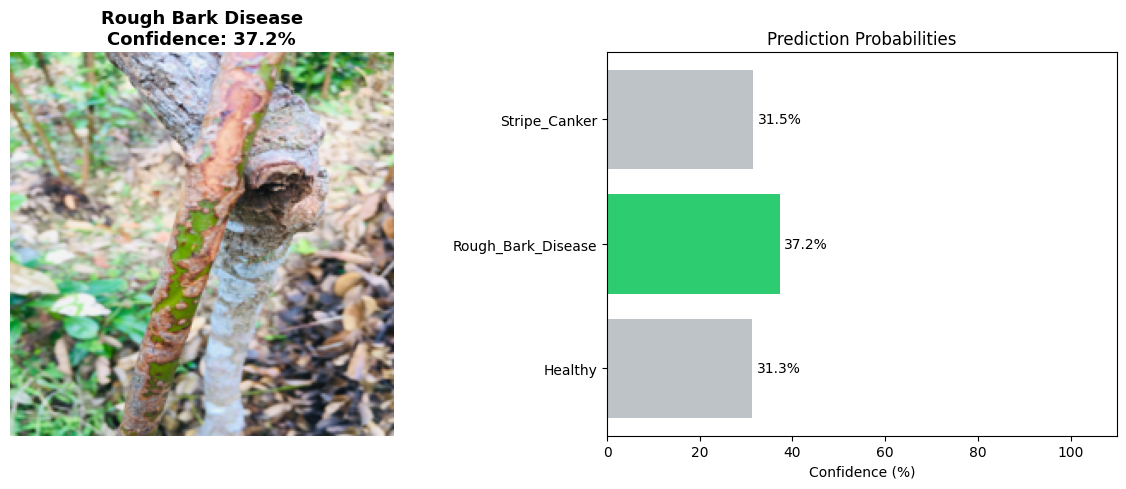


 Result   : Rough Bark Disease
 Confidence: 37.23%
 Advice   :  Apply copper fungicide. Remove infected bark. Improve drainage.


In [29]:
from google.colab import files

DISEASE_ADVICE = {
    'Healthy':             ' Plant is healthy. Continue regular care.',
    'Rough_Bark_Disease':  ' Apply copper fungicide. Remove infected bark. Improve drainage.',
    'Stripe_Canker':       ' Improve soil drainage. Remove infected parts. Apply phosphonate.',
}

def predict_image(img_path, model):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img) / 255.0, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    idx = np.argmax(probs)
    cls = CLASSES[idx]
    conf = probs[idx] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f"{cls.replace('_',' ')}\nConfidence: {conf:.1f}%", fontsize=13, fontweight='bold')

    colors = ['#2ecc71' if c == cls else '#bdc3c7' for c in CLASSES]
    ax2.barh(CLASSES, probs * 100, color=colors)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Prediction Probabilities')
    ax2.set_xlim(0, 110)
    for i, p in enumerate(probs):
        ax2.text(p*100 + 1, i, f'{p*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    print(f"\n Result   : {cls.replace('_', ' ')}")
    print(f" Confidence: {conf:.2f}%")
    print(f" Advice   : {DISEASE_ADVICE[cls]}")

# Upload and predict
print("Upload a cinnamon plant image:")
uploaded = files.upload()
for fname in uploaded:
    predict_image(fname, best_model)

**Save & Download Model**

In [ ]:
import json
from google.colab import files

# Save full model
best_model.save('/content/cinnamon_disease_final.keras')

# Save TFLite version (for mobile apps)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/cinnamon_disease.tflite', 'wb') as f:
    f.write(tflite_model)

# Save class labels
with open('/content/class_names.json', 'w') as f:
    json.dump(CLASSES, f)

print("All files saved! Downloading...")
files.download('/content/cinnamon_disease_final.keras')
files.download('/content/cinnamon_disease.tflite')
files.download('/content/class_names.json')

Saved artifact at '/tmp/tmpbbis7rll'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139952331562768: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139952331563536: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139953437074320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336815312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336814928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336816464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336814352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139952336815888: TensorSpec(shape=(), dtype=tf.resource, name=Non

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>